# Ejercicio 1: limpia el dataset y realiza las transformaciones necesarias

In [11]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer

df = pd.read_csv("Customer.csv")

df_clean = df.copy()

# Quitamos ID porque es un identificador único y no aporta información generalizable
df_clean = df_clean.drop(columns=["ID"])

# Eliminamos las filas sin target porque no se pueden usar en aprendizaje supervisado
df_clean = df_clean.dropna(subset=["Segmentation"])

# Imputación de variables numéricas
num_cols_with_na = ["Work_Experience", "Family_Size"]
num_imputer = SimpleImputer(strategy="median")
df_clean[num_cols_with_na] = num_imputer.fit_transform(df_clean[num_cols_with_na])

# Imputación de variables categóricas
cat_cols_with_na = ["Ever_Married", "Graduated", "Profession", "Var_1"]
cat_imputer = SimpleImputer(strategy="most_frequent")
df_clean[cat_cols_with_na] = cat_imputer.fit_transform(df_clean[cat_cols_with_na])

# Comprobación final
df_clean.isnull().sum()

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

Para preparar el dataset se ha eliminado la columna `ID`, ya que se trata de un identificador único de cada cliente y no representa una característica útil para generalizar sobre nuevos datos.

También se han eliminado las filas en las que la variable objetivo `Segmentation` no tiene valor, ya que el problema planteado es de aprendizaje supervisado y necesitamos conocer la clase real de cada muestra para poder entrenar y evaluar el modelo.

Para los valores ausentes de variables numéricas, como `Work_Experience` y `Family_Size`, se ha aplicado imputación mediante la mediana. Esta decisión es adecuada porque ambas variables son numéricas y la mediana es una medida robusta frente a posibles valores extremos.

Para los valores ausentes de variables categóricas, como `Ever_Married`, `Graduated`, `Profession` y `Var_1`, se ha aplicado imputación mediante la moda, es decir, el valor más frecuente. Esta opción permite conservar las muestras sin introducir nuevas categorías artificiales y es una estrategia sencilla y razonable para atributos categóricos.

Tras estas transformaciones, el dataset queda sin valores nulos y preparado para aplicar codificación de variables categóricas y escalado de variables numéricas antes de entrenar los modelos.

In [12]:
# Separamos entradas y salida
X = df_clean.drop(columns=["Segmentation"])
y = df_clean["Segmentation"]

# Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)

Columnas numéricas: ['Age', 'Work_Experience', 'Family_Size']
Columnas categóricas: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", one_hot, cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [15]:
X_processed.shape

(8068, 28)

In [16]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['A' 'B' 'C' 'D']


In [17]:
num_classes = len(label_encoder.classes_)

y_one_hot = np.eye(num_classes)[y_encoded]

y_one_hot.shape

(8068, 4)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=13,
    stratify=y_encoded
)

y_train_one_hot = np.eye(num_classes)[y_train]
y_test_one_hot = np.eye(num_classes)[y_test]

# Comprobación
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("y_train_one_hot:", y_train_one_hot.shape)
print("y_test_one_hot:", y_test_one_hot.shape)

X_train: (6454, 28)
X_test: (1614, 28)
y_train: (6454,)
y_test: (1614,)
y_train_one_hot: (6454, 4)
y_test_one_hot: (1614, 4)


Una vez limpiado el dataset, se han separado las variables de entrada `X` y la variable objetivo `Segmentation`.

Las variables numéricas (`Age`, `Work_Experience` y `Family_Size`) se han escalado mediante `StandardScaler`, ya que modelos como el perceptrón multicapa y KNN son sensibles a la escala de las entradas.

Las variables categóricas (`Gender`, `Ever_Married`, `Graduated`, `Profession`, `Spending_Score` y `Var_1`) se han transformado mediante `OneHotEncoder`, ya que no tienen una representación numérica directa adecuada para los modelos de machine learning.

La variable objetivo `Segmentation` se ha codificado con `LabelEncoder`, transformando las clases `A`, `B`, `C` y `D` en valores numéricos. Además, se ha preparado una versión one-hot de la salida para poder usarla en el perceptrón multicapa propio.

Finalmente, se ha realizado una partición de entrenamiento y test con `test_size=0.2` y `random_state=13`, tal como indica el enunciado.

# Ejercicio 2: representa gráficamente los datos

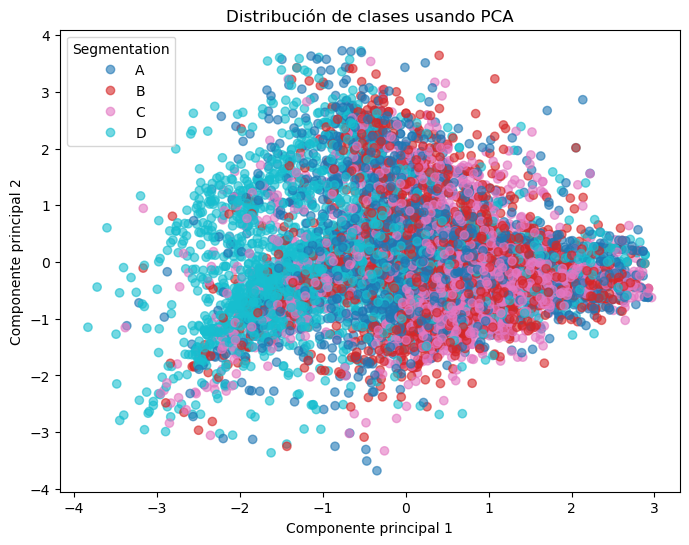

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=13)

X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_encoded,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Distribución de clases usando PCA")

handles, _ = scatter.legend_elements()
plt.legend(handles, label_encoder.classes_, title="Segmentation")

plt.show()

Para representar gráficamente la distribución de las clases se ha aplicado PCA sobre el dataset ya transformado. Como tras la codificación one-hot y el escalado existen 28 variables de entrada, no es posible representar directamente todas las dimensiones en un gráfico 2D.

PCA permite proyectar los datos en dos componentes principales, conservando la mayor cantidad posible de variabilidad. En el gráfico, cada punto representa un cliente y el color indica la clase real de `Segmentation`.

Este gráfico permite observar de forma visual si las clases aparecen claramente separadas o si, por el contrario, se solapan. Si las clases están muy mezcladas, será más difícil que los modelos consigan una precisión alta.

# Ejercicio 3: modelo de predicción

In [30]:
from MLPGeneral import MLPGeneral

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mlp_3_hidden = MLPGeneral(
    inputLayer=X_train.shape[1],
    hiddenLayers=[64, 32, 16],
    outputLayer=num_classes,
    seed=13,
    epislom=0.12
)

Jhistory_3_hidden = mlp_3_hidden.backpropagation(
    X_train,
    y_train_one_hot,
    alpha=0.5,
    lambda_=0.0,
    numIte=700,
    verbose=100
)

activations_train, _ = mlp_3_hidden.feedforward(X_train)
activations_test, _ = mlp_3_hidden.feedforward(X_test)

y_pred_train_3_hidden = mlp_3_hidden.predict(activations_train[-1])
y_pred_test_3_hidden = mlp_3_hidden.predict(activations_test[-1])

acc_train_3_hidden = accuracy_score(y_train, y_pred_train_3_hidden)
acc_test_3_hidden = accuracy_score(y_test, y_pred_test_3_hidden)

print("Accuracy train MLP 3 capas ocultas:", acc_train_3_hidden)
print("Accuracy test MLP 3 capas ocultas:", acc_test_3_hidden)

Iteration      1: Cost   2.8418
Iteration    101: Cost   2.2456
Iteration    201: Cost   2.2456
Iteration    301: Cost   2.2456
Iteration    401: Cost   2.2456
Iteration    501: Cost   2.2455
Iteration    601: Cost   2.2455
Iteration    700: Cost   2.2455
Accuracy train MLP 3 capas ocultas: 0.28106600557793615
Accuracy test MLP 3 capas ocultas: 0.2812887236679058


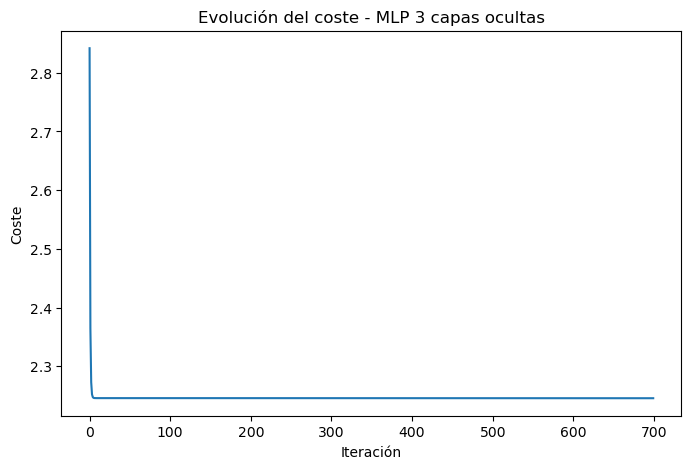

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(Jhistory_3_hidden)
plt.xlabel("Iteración")
plt.ylabel("Coste")
plt.title("Evolución del coste - MLP 3 capas ocultas")
plt.show()

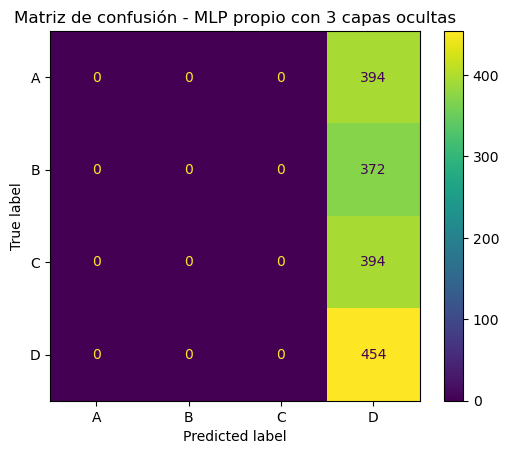

In [32]:
cm_3_hidden = confusion_matrix(y_test, y_pred_test_3_hidden)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_3_hidden,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Matriz de confusión - MLP propio con 3 capas ocultas")
plt.show()

In [33]:
from MLP import MLP

mlp_simple = MLP(
    X_train.shape[1],
    25,
    num_classes,
    seed=13,
    epislom=0.12
)

Jhistory_simple = mlp_simple.backpropagation(
    X_train,
    y_train_one_hot,
    alpha=0.5,
    lambda_=0.0,
    numIte=700,
    verbose=100
)

a3_train_simple = mlp_simple.feedforward(X_train)[2]
a3_test_simple = mlp_simple.feedforward(X_test)[2]

y_pred_train_simple = mlp_simple.predict(a3_train_simple)
y_pred_test_simple = mlp_simple.predict(a3_test_simple)

acc_train_simple = accuracy_score(y_train, y_pred_train_simple)
acc_test_simple = accuracy_score(y_test, y_pred_test_simple)

print("Accuracy train MLP simple:", acc_train_simple)
print("Accuracy test MLP simple:", acc_test_simple)

Iteration      1: Cost   2.9480   
Iteration    101: Cost   1.9872   
Iteration    201: Cost   1.9222   
Iteration    301: Cost   1.8994   
Iteration    401: Cost   1.8844   
Iteration    501: Cost   1.8740   
Iteration    601: Cost   1.8664   
Iteration    700: Cost   1.8604   
Accuracy train MLP simple: 0.5148744964363186
Accuracy test MLP simple: 0.5006195786864932


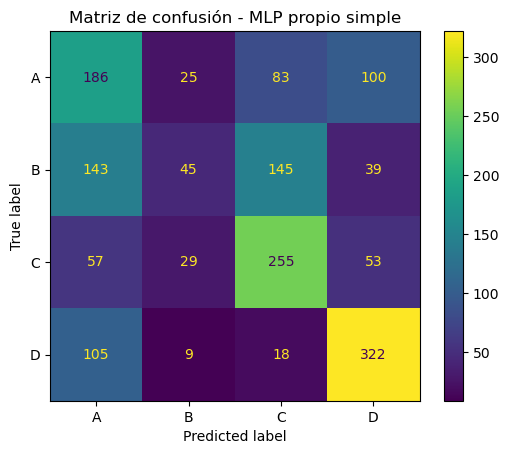

In [34]:
cm_simple = confusion_matrix(y_test, y_pred_test_simple)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_simple,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Matriz de confusión - MLP propio simple")
plt.show()

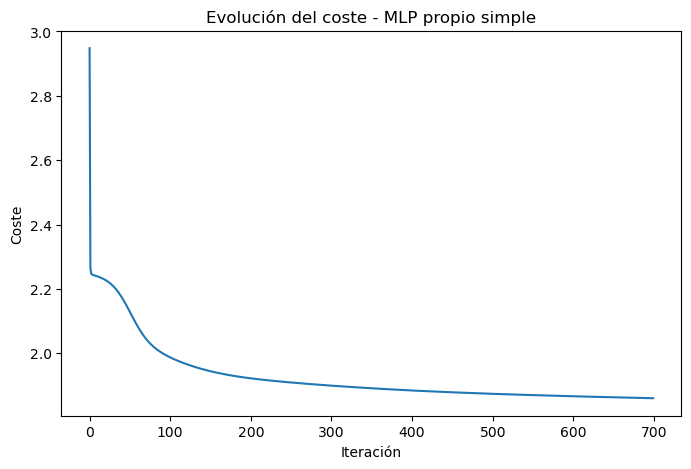

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(Jhistory_simple)
plt.xlabel("Iteración")
plt.ylabel("Coste")
plt.title("Evolución del coste - MLP propio simple")
plt.show()

In [36]:
resultados_ej3 = pd.DataFrame([
    {
        "modelo": "MLP propio simple",
        "arquitectura": f"{X_train.shape[1]} -> 25 -> {num_classes}",
        "accuracy_train": acc_train_simple,
        "accuracy_test": acc_test_simple
    },
    {
        "modelo": "MLP propio 3 capas ocultas",
        "arquitectura": f"{X_train.shape[1]} -> 64 -> 32 -> 16 -> {num_classes}",
        "accuracy_train": acc_train_3_hidden,
        "accuracy_test": acc_test_3_hidden
    }
])

resultados_ej3

,modelo,arquitectura,accuracy_train,accuracy_test
0,MLP propio simple,28 -> 25 -> 4,0.514874,0.500620
1,MLP propio 3 capas ocultas,28 -> 64 -> 32 -> 16 -> 4,0.281066,0.281289


In [37]:
modelo_final_mlp = mlp_simple
y_pred_final_mlp = y_pred_test_simple
acc_final_mlp = acc_test_simple

print("Modelo final elegido: MLP propio simple")
print("Accuracy final:", acc_final_mlp)

Modelo final elegido: MLP propio simple
Accuracy final: 0.5006195786864932


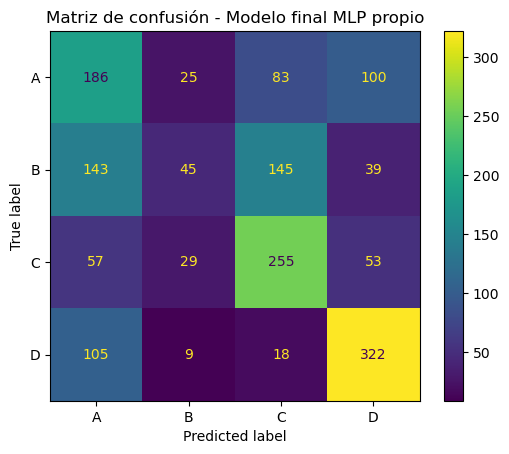

In [38]:
cm_final_mlp = confusion_matrix(y_test, y_pred_final_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final_mlp,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Matriz de confusión - Modelo final MLP propio")
plt.show()

Se ha probado un MLP con tres capas ocultas para cumplir el requisito del enunciado. El modelo con tres capas ocultas obtiene un accuracy cercano al 28%, un valor próximo al rendimiento que se obtendría prediciendo siempre la clase mayoritaria. Por tanto, esta configuración no está aprendiendo una frontera de decisión útil para el problema.

Aunque una red con más capas tiene más capacidad, esto no implica necesariamente un mejor resultado. En este caso, la red profunda es más difícil de entrenar y puede verse afectada por problemas como saturación de la sigmoide, peor propagación del gradiente o una configuración de hiperparámetros poco adecuada.

El modelo final elegido es el MLP propio simple, ya que consigue un accuracy superior al 50% en test y presenta un comportamiento más estable. Por ello, se considera que generaliza mejor para este dataset.


# Ejercicio 4: MLPClassifier de SKLearn

In [42]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [43]:
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=13
)

mlp_sklearn.fit(X_train, y_train)

y_pred_mlp_sklearn_train = mlp_sklearn.predict(X_train)
y_pred_mlp_sklearn_test = mlp_sklearn.predict(X_test)

acc_train_mlp_sklearn = accuracy_score(y_train, y_pred_mlp_sklearn_train)
acc_test_mlp_sklearn = accuracy_score(y_test, y_pred_mlp_sklearn_test)

print("Accuracy train MLPClassifier:", acc_train_mlp_sklearn)
print("Accuracy test MLPClassifier:", acc_test_mlp_sklearn)

Accuracy train MLPClassifier: 0.6651688875116207
Accuracy test MLPClassifier: 0.5030978934324659


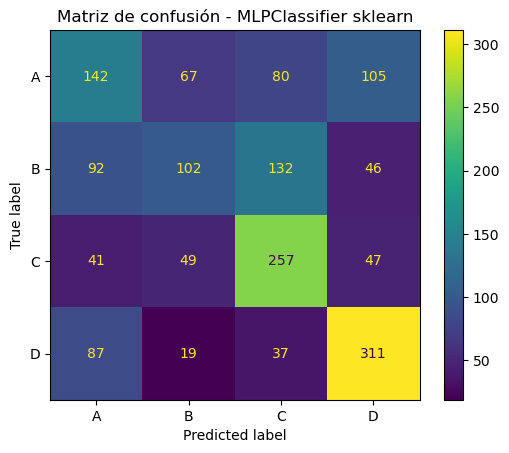

In [44]:
cm_mlp_sklearn = confusion_matrix(y_test, y_pred_mlp_sklearn_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp_sklearn,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Matriz de confusión - MLPClassifier sklearn")
plt.show()

Se ha entrenado un modelo `MLPClassifier` de sklearn para resolver el problema de clasificación multiclase de `Segmentation`.

A diferencia del perceptrón multicapa implementado manualmente, `MLPClassifier` proporciona una implementación más optimizada y permite usar funciones de activación como ReLU y optimizadores como Adam. Se han usado los mismos datos preprocesados que en el ejercicio anterior, con variables numéricas escaladas y variables categóricas codificadas mediante one-hot encoding.

El modelo obtiene un accuracy de entrenamiento de 66,5169 % y un accuracy de test de 50,3098 %. Por tanto, supera el mínimo del 50% indicado en el enunciado. Además, se ha representado la matriz de confusión para analizar qué clases se clasifican correctamente y entre qué segmentos se producen más errores.

# Ejercicio 5: KNN

In [46]:
from sklearn.neighbors import KNeighborsClassifier

resultados_knn = []

best_knn = None
best_acc_knn = -1
best_k = None

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    
    pred_train = knn.predict(X_train)
    pred_test = knn.predict(X_test)
    
    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)
    
    resultados_knn.append({
        "k": k,
        "accuracy_train": acc_train,
        "accuracy_test": acc_test
    })
    
    if acc_test > best_acc_knn:
        best_acc_knn = acc_test
        best_knn = knn
        best_k = k

resultados_knn_df = pd.DataFrame(resultados_knn)
resultados_knn_df.sort_values("accuracy_test", ascending=False).head(10)

,k,accuracy_train,accuracy_test
15,16,0.560738,0.513011
13,14,0.568175,0.509294
28,29,0.543384,0.509294
26,27,0.546948,0.509294
20,21,0.551441,0.509294
29,30,0.544623,0.509294
27,28,0.545708,0.508674
21,22,0.548342,0.506196
9,10,0.584444,0.505576
16,17,0.557484,0.504957


In [47]:
print("Mejor k:", best_k)
print("Mejor accuracy test KNN:", best_acc_knn)

knn_final = best_knn

y_pred_knn_train = knn_final.predict(X_train)
y_pred_knn_test = knn_final.predict(X_test)

acc_train_knn = accuracy_score(y_train, y_pred_knn_train)
acc_test_knn = accuracy_score(y_test, y_pred_knn_test)

print("Accuracy train KNN:", acc_train_knn)
print("Accuracy test KNN:", acc_test_knn)

Mejor k: 16
Mejor accuracy test KNN: 0.5130111524163569
Accuracy train KNN: 0.5607375271149675
Accuracy test KNN: 0.5130111524163569


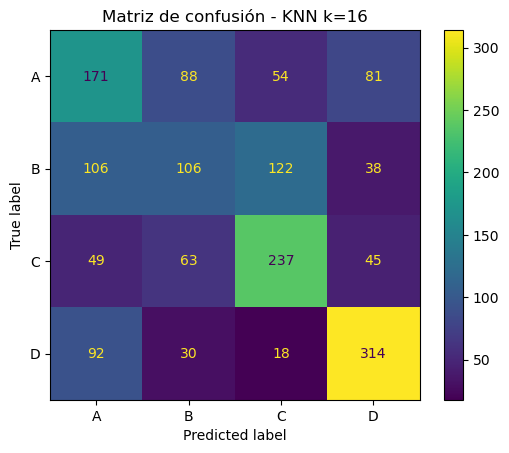

In [48]:
cm_knn = confusion_matrix(y_test, y_pred_knn_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title(f"Matriz de confusión - KNN k={best_k}")
plt.show()

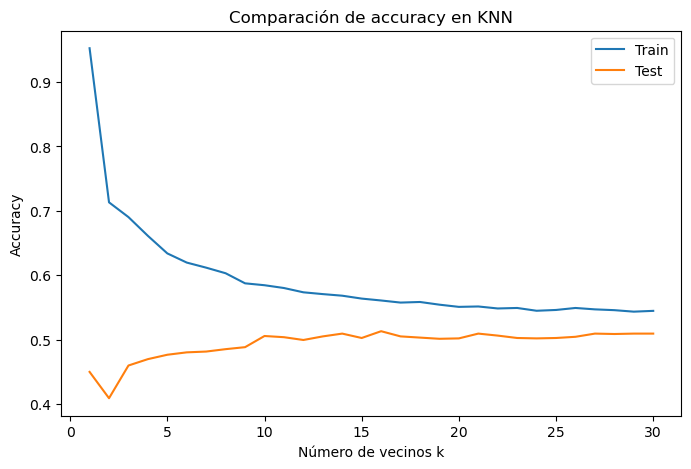

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_knn_df["k"], resultados_knn_df["accuracy_train"], label="Train")
plt.plot(resultados_knn_df["k"], resultados_knn_df["accuracy_test"], label="Test")
plt.xlabel("Número de vecinos k")
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy en KNN")
plt.legend()
plt.show()

Se ha entrenado un modelo KNN para clasificar los clientes según su segmento. Este algoritmo asigna la clase de una muestra en función de las clases de sus vecinos más cercanos.

Se han probado distintos valores de `k`, ya que este hiperparámetro controla el número de vecinos utilizados para tomar la decisión. Un valor de `k` demasiado bajo puede provocar sobreajuste, porque el modelo se vuelve muy sensible a ejemplos concretos del conjunto de entrenamiento. Un valor de `k` demasiado alto puede suavizar demasiado la frontera de decisión y provocar infraajuste.

El mejor resultado se obtiene con `k = 16`, alcanzando un accuracy de test de 51,3011 %. Por tanto, supera el mínimo del 48% indicado en el enunciado.

# Ejercicio 5: RandomForestClassifier

In [52]:
from sklearn.ensemble import RandomForestClassifier

configs_rf = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 15, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 2},
]

resultados_rf = []

best_rf = None
best_acc_rf = -1
best_config_rf = None

for config in configs_rf:
    modelo = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=13,
        n_jobs=-1
    )
    
    modelo.fit(X_train, y_train)
    
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    
    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)
    
    resultados_rf.append({
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_leaf": config["min_samples_leaf"],
        "accuracy_train": acc_train,
        "accuracy_test": acc_test
    })
    
    if acc_test > best_acc_rf:
        best_acc_rf = acc_test
        best_rf = modelo
        best_config_rf = config

resultados_rf_df = pd.DataFrame(resultados_rf)
resultados_rf_df.sort_values("accuracy_test", ascending=False)

,n_estimators,max_depth,min_samples_leaf,accuracy_train,accuracy_test
3,200,10.0,1,0.682522,0.542751
6,300,15.0,2,0.747134,0.541512
4,200,15.0,1,0.892780,0.527261
1,200,NaN,1,0.955067,0.503717
2,300,NaN,1,0.955067,0.501239
5,200,20.0,1,0.949799,0.501239
0,100,NaN,1,0.955067,0.495043


In [53]:
print("Mejor configuración RandomForest:", best_config_rf)
print("Mejor accuracy test RandomForest:", best_acc_rf)

rf_final = best_rf

y_pred_rf_train = rf_final.predict(X_train)
y_pred_rf_test = rf_final.predict(X_test)

acc_train_rf = accuracy_score(y_train, y_pred_rf_train)
acc_test_rf = accuracy_score(y_test, y_pred_rf_test)

Mejor configuración RandomForest: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1}
Mejor accuracy test RandomForest: 0.5427509293680297


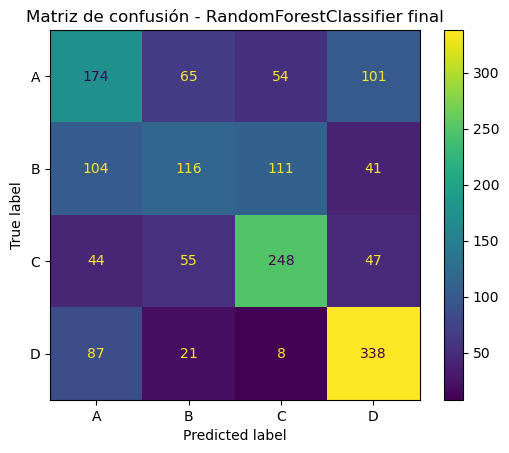

In [54]:
cm_rf = confusion_matrix(y_test, y_pred_rf_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Matriz de confusión - RandomForestClassifier final")
plt.show()

Se ha entrenado un modelo `RandomForestClassifier`, que combina múltiples árboles de decisión para realizar la clasificación. Este tipo de modelo suele funcionar bien en datasets tabulares, ya que puede capturar relaciones no lineales entre las variables y reduce la dependencia de un único árbol mediante el uso de varios estimadores.

Se han probado distintas configuraciones modificando el número de árboles, la profundidad máxima y el número mínimo de muestras por hoja. El mejor modelo obtiene un accuracy de test de 54,2751 %, superando el mínimo del 53% indicado en el enunciado.

La matriz de confusión permite observar qué segmentos de clientes se clasifican mejor y cuáles se confunden con mayor frecuencia.

# Ejercicio 5: análisis train / validación

In [55]:
resumen_modelos = pd.DataFrame([
    {
        "modelo": "MLP propio simple",
        "accuracy_train": acc_train_simple,
        "accuracy_test": acc_test_simple
    },
    {
        "modelo": "MLPClassifier sklearn",
        "accuracy_train": acc_train_mlp_sklearn,
        "accuracy_test": acc_test_mlp_sklearn
    },
    {
        "modelo": f"KNN k={best_k}",
        "accuracy_train": acc_train_knn,
        "accuracy_test": acc_test_knn
    },
    {
        "modelo": "RandomForestClassifier",
        "accuracy_train": acc_train_rf,
        "accuracy_test": acc_test_rf
    }
])

resumen_modelos["diferencia_train_test"] = (
    resumen_modelos["accuracy_train"] - resumen_modelos["accuracy_test"]
)

resumen_modelos

,modelo,accuracy_train,accuracy_test,diferencia_train_test
0,MLP propio simple,0.514874,0.500620,0.014255
1,MLPClassifier sklearn,0.665169,0.503098,0.162071
2,KNN k=16,0.560738,0.513011,0.047726
3,RandomForestClassifier,0.682522,0.542751,0.139772


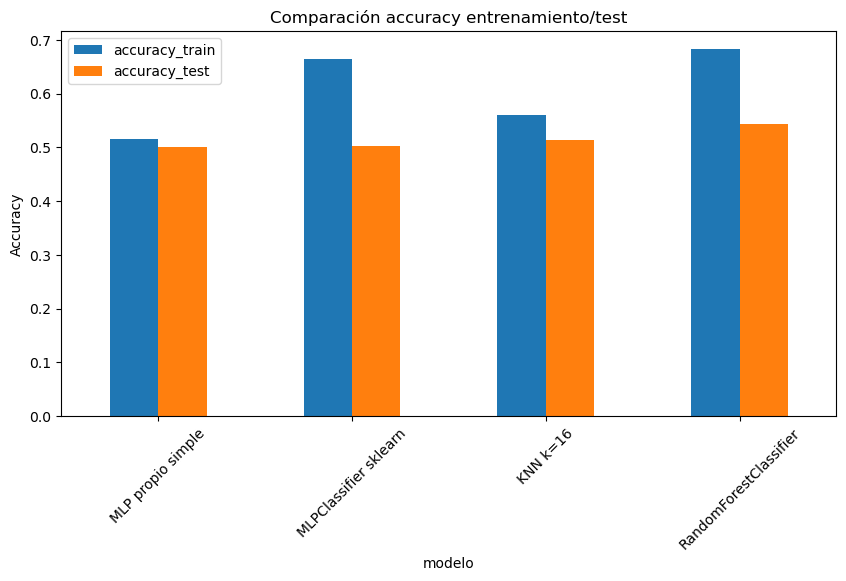

In [56]:
resumen_modelos.plot(
    x="modelo",
    y=["accuracy_train", "accuracy_test"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Accuracy")
plt.title("Comparación accuracy entrenamiento/test")
plt.xticks(rotation=45)
plt.show()

Se ha comparado el accuracy de entrenamiento y de test de los distintos modelos entrenados.

El accuracy de entrenamiento indica cómo de bien se ajusta el modelo a los datos con los que ha aprendido, mientras que el accuracy de test permite estimar su capacidad de generalización ante datos no vistos.

Si un modelo obtiene un accuracy de entrenamiento muy superior al de test, podemos sospechar sobreajuste, ya que el modelo estaría aprendiendo demasiado bien las particularidades del conjunto de entrenamiento pero no generalizaría igual de bien. Si ambos accuracies son bajos, podríamos hablar de infraajuste, ya que el modelo no tendría suficiente capacidad para aprender correctamente el patrón de los datos o las variables disponibles no serían suficientemente informativas.

En los resultados obtenidos, el modelo RandomForestClassifier presenta el mejor accuracy de test, con un valor de 54,2751 %. Por tanto, es el modelo que mejor generaliza entre los probados. El modelo MLPClassifier presenta una diferencia mayor entre entrenamiento y test, lo que puede indicar cierto sobreajuste.

Para mejorar los resultados podrían aplicarse varias estrategias: ajustar hiperparámetros, modificar la complejidad de los modelos, aplicar regularización, utilizar validación cruzada, probar nuevas transformaciones de variables o disponer de más datos. En el caso de KNN, sería importante elegir adecuadamente el número de vecinos. En el caso de RandomForest, se podría limitar la profundidad de los árboles o aumentar el número mínimo de muestras por hoja para reducir el sobreajuste.

Aunque RandomForest es el modelo con mejor accuracy de test, también presenta cierta diferencia entre entrenamiento y test. Esto puede indicar algo de sobreajuste, aunque menor que en modelos de bosque sin limitar la profundidad. La configuración elegida con `max_depth=10` reduce ese sobreajuste frente a árboles sin profundidad máxima.

# Ejercicio 6: MLPReLU

In [57]:
from MLPRelu import MLPRelu

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mlp_relu_sigmoid = MLPRelu(
    inputLayer=X_train.shape[1],
    hiddenLayer=25,
    outputLayer=num_classes,
    seed=13,
    epislom=0.12,
    function="sigmoid",
    out_function="sigmoid"
)

Jhistory_relu_sigmoid = mlp_relu_sigmoid.backpropagation(
    X_train,
    y_train_one_hot,
    alpha=0.5,
    lambda_=0.0,
    numIte=700,
    verbose=100
)

a3_train_relu_sigmoid = mlp_relu_sigmoid.feedforward(X_train)[2]
a3_test_relu_sigmoid = mlp_relu_sigmoid.feedforward(X_test)[2]

y_pred_train_relu_sigmoid = mlp_relu_sigmoid.predict(a3_train_relu_sigmoid)
y_pred_test_relu_sigmoid = mlp_relu_sigmoid.predict(a3_test_relu_sigmoid)

acc_train_relu_sigmoid = accuracy_score(y_train, y_pred_train_relu_sigmoid)
acc_test_relu_sigmoid = accuracy_score(y_test, y_pred_test_relu_sigmoid)

print("Accuracy train MLPRelu sigmoid + sigmoid:", acc_train_relu_sigmoid)
print("Accuracy test MLPRelu sigmoid + sigmoid:", acc_test_relu_sigmoid)

Iteration      1: Cost   2.9480
Iteration    101: Cost   1.9872
Iteration    201: Cost   1.9222
Iteration    301: Cost   1.8994
Iteration    401: Cost   1.8844
Iteration    501: Cost   1.8740
Iteration    601: Cost   1.8664
Iteration    700: Cost   1.8604
Accuracy train MLPRelu sigmoid + sigmoid: 0.5148744964363186
Accuracy test MLPRelu sigmoid + sigmoid: 0.5006195786864932


In [58]:
mlp_relu_softmax = MLPRelu(
    inputLayer=X_train.shape[1],
    hiddenLayer=25,
    outputLayer=num_classes,
    seed=13,
    epislom=0.12,
    function="relu",
    out_function="softmax"
)

Jhistory_relu_softmax = mlp_relu_softmax.backpropagation(
    X_train,
    y_train_one_hot,
    alpha=0.5,
    lambda_=0.0,
    numIte=700,
    verbose=100
)

a3_train_relu_softmax = mlp_relu_softmax.feedforward(X_train)[2]
a3_test_relu_softmax = mlp_relu_softmax.feedforward(X_test)[2]

y_pred_train_relu_softmax = mlp_relu_softmax.predict(a3_train_relu_softmax)
y_pred_test_relu_softmax = mlp_relu_softmax.predict(a3_test_relu_softmax)

acc_train_relu_softmax = accuracy_score(y_train, y_pred_train_relu_softmax)
acc_test_relu_softmax = accuracy_score(y_test, y_pred_test_relu_softmax)

print("Accuracy train MLPRelu ReLU + softmax:", acc_train_relu_softmax)
print("Accuracy test MLPRelu ReLU + softmax:", acc_test_relu_softmax)

Iteration      1: Cost   1.3877
Iteration    101: Cost   1.0949
Iteration    201: Cost   1.0788
Iteration    301: Cost   1.0684
Iteration    401: Cost   1.0586
Iteration    501: Cost   1.0495
Iteration    601: Cost   1.0425
Iteration    700: Cost   1.0369
Accuracy train MLPRelu ReLU + softmax: 0.5503563681437867
Accuracy test MLPRelu ReLU + softmax: 0.5322180916976456


In [59]:
# Tabla comparativa
resultados_ej6 = pd.DataFrame([
    {
        "modelo": "MLPRelu sigmoid + sigmoid",
        "hidden": 25,
        "alpha": 0.5,
        "lambda": 0.0,
        "iteraciones": 700,
        "accuracy_train": acc_train_relu_sigmoid,
        "accuracy_test": acc_test_relu_sigmoid
    },
    {
        "modelo": "MLPRelu ReLU + softmax",
        "hidden": 25,
        "alpha": 0.5,
        "lambda": 0.0,
        "iteraciones": 700,
        "accuracy_train": acc_train_relu_softmax,
        "accuracy_test": acc_test_relu_softmax
    }
])

resultados_ej6

,modelo,hidden,alpha,lambda,iteraciones,accuracy_train,accuracy_test
0,MLPRelu sigmoid + sigmoid,25,0.5,0.0,700,0.514874,0.500620
1,MLPRelu ReLU + softmax,25,0.5,0.0,700,0.550356,0.532218


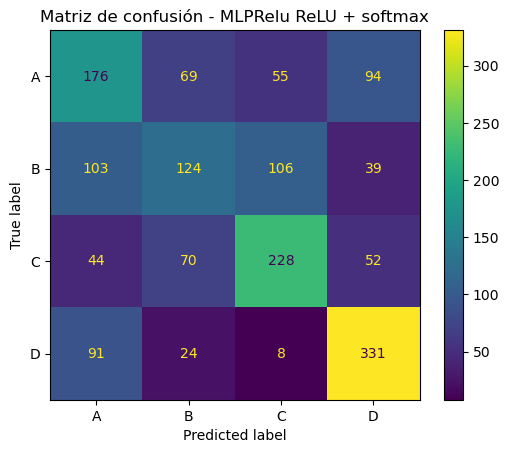

In [60]:
# Matriz de confusión para ReLU + softmax
cm_relu_softmax = confusion_matrix(y_test, y_pred_test_relu_softmax)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_relu_softmax,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Matriz de confusión - MLPRelu ReLU + softmax")
plt.show()

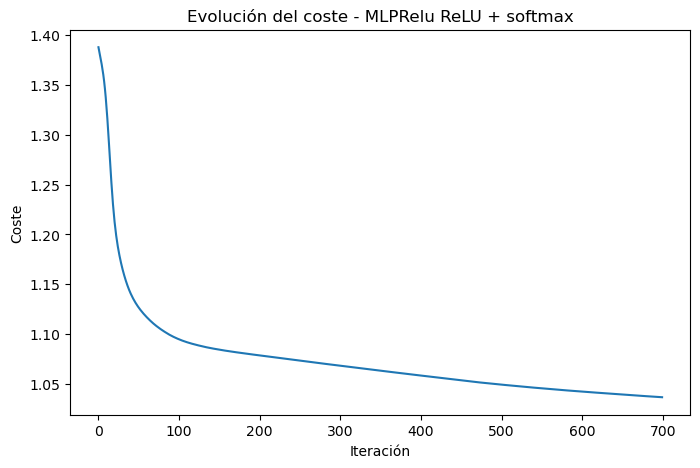

In [62]:
# Gráfica del coste
plt.figure(figsize=(8, 5))
plt.plot(Jhistory_relu_softmax)
plt.xlabel("Iteración")
plt.ylabel("Coste")
plt.title("Evolución del coste - MLPRelu ReLU + softmax")
plt.show()

En este ejercicio se ha creado una copia modificada del perceptrón multicapa llamada `MLPRelu`. Esta versión mantiene la estructura del MLP utilizado en las prácticas, pero añade la posibilidad de escoger la función de activación de la capa oculta y la función de activación de la capa de salida.

En las capas ocultas se permite usar `sigmoid` o `relu`. La función sigmoidal transforma la activación a valores entre 0 y 1, mientras que ReLU devuelve 0 para valores negativos y mantiene los valores positivos. Su derivada se ha implementado como `(a > 0) * 1`, siguiendo lo indicado en el enunciado.

En la capa de salida se permite usar `sigmoid` o `softmax`. Para este problema de clasificación multiclase, `softmax` resulta especialmente adecuada porque convierte las salidas del modelo en una distribución de probabilidad sobre las cuatro clases posibles de `Segmentation`.

También se ha modificado el cálculo del coste para utilizar `xlogy` de `scipy.special`, evitando problemas numéricos asociados a calcular `log(0)`. En el caso de `softmax`, se utiliza la entropía cruzada multiclase.

Se han entrenado dos configuraciones: una con `sigmoid` en la capa oculta y `sigmoid` en la salida, y otra con `relu` en la capa oculta y `softmax` en la salida. El modelo con ReLU y softmax obtiene un accuracy de entrenamiento de 55,0356 % y un accuracy de test de 53,2218 %, dando un resultado similar al obtenido con la versión sigmoidal y demostrando que la modificación funciona correctamente.